In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (1).csv


In [6]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [10]:
df.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace =True)

In [11]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df.isnull().sum()

,0
v1,0
v2,0


In [13]:
df.duplicated().sum()

np.int64(403)

In [14]:
df = df.drop_duplicates(keep='first')

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df = df.rename(columns = {'v1':'target','v2':'text'})

In [17]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [19]:
df['target'] = le.fit_transform(df['target'])

In [20]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
df['target'].value_counts()

,count
target,
0,4516
1,653


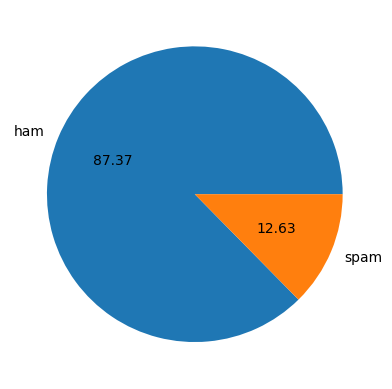

In [22]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [23]:
#lowercasing
df['text'] = df['text'].str.lower()

In [24]:
df.head()

,target,text
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [ ]:
#remove punctuation
import string
def remove_punc(txt):
  return txt.translate(str.maketrans('', '', string.punctuation))

In [ ]:
df['text'] = df['text'].apply(remove_punc)

In [25]:
df.head()

,target,text
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [26]:
#remove number
def remove_number(txt):
  new = ""
  for i in txt:
    if not i.isdigit():
      new += i
  return new
df['text'] = df['text'].apply(remove_number)

In [27]:
import re

In [28]:
#remove urls
def remove_html_tags(txt):
  pattern = re.compile('<.*?>')
  return pattern.sub(r'',txt)
df['text'] = df['text'].apply(remove_html_tags)

In [29]:
#remove emojis
def remove_emojis(txt):
  new = ""
  for i in txt:
    if i.isascii():
      new += i
  return new
df['text'] = df['text'].apply(remove_emojis)
df

,target,text
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in a wkly comp to win fa cup final...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."
...,...,...
5567,1,this is the nd time we have tried contact u. ...
5568,0,will _ b going to esplanade fr home?
5569,0,"pity, * was in mood for that. so...any other s..."
5570,0,the guy did some bitching but i acted like i'd...


In [30]:
import nltk

In [31]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [32]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [33]:
#check set of stopwords you can check of many lang
stop_words = set(stopwords.words('english'))
len(stop_words)
#

198

In [34]:
df.loc[11]['text']

'six chances to win cash! from  to , pounds txt> csh and send to . cost p/day, days, + tsandcs apply reply hl  info'

In [35]:
def remove_stopwords(txt):
  words = txt.split()
  cleaned = []
  for i in words:
    if i not in stop_words:
      cleaned.append(i)
  return ' '.join(cleaned)

In [36]:
df['text'] = df['text'].apply(remove_stopwords)

In [37]:
df.loc[11]['text']

'six chances win cash! , pounds txt> csh send . cost p/day, days, + tsandcs apply reply hl info'

In [38]:
#stemming

In [39]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def stem_text(txt):
    words = txt.split()
    stemmed = [ps.stem(word) for word in words]
    return " ".join(stemmed)

df['text'] = df['text'].apply(stem_text)

In [55]:
#applying tdidf
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['text'])

In [56]:
y = df['target']

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
#model training
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [59]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [60]:
y_pred = model.predict(X_test)

In [61]:
y_pred

array([0, 0, 0, ..., 1, 0, 0])

In [62]:
y_test

,target
1617,0
2064,0
1272,0
3020,0
3642,0
...,...
4146,0
1208,0
4795,1
3575,0


In [63]:
accuracy_score(y_test,y_pred)

0.97678916827853

In [64]:
confusion_matrix(y_test,y_pred)

array([[888,   1],
       [ 23, 122]])

In [65]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       0.99      0.84      0.91       145

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [66]:
print("Training Accuracy:", model.score(X_train, y_train))


Training Accuracy: 0.9794437726723095


In [67]:
print("Testing Accuracy:", model.score(X_test, y_test))

Testing Accuracy: 0.97678916827853


In [68]:
from sklearn.linear_model import LogisticRegression

In [69]:
model_lr = LogisticRegression(max_iter = 1000)

In [70]:
model_lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [71]:
y_pred = model_lr.predict(X_test)

In [72]:
y_pred

array([0, 0, 0, ..., 1, 0, 0])

In [73]:
accuracy_score(y_test,y_pred)

0.9680851063829787

In [74]:
confusion_matrix(y_test,y_pred)

array([[887,   2],
       [ 31, 114]])

In [51]:
import joblib

In [75]:
joblib.dump(model,'spam_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']